In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# overall pack values

#mass
m_cells = 5.68 #kg
m_al = .338 #kg

#specific heat #J/kg*K
c_cells = 775
c_al = 880

#internal resistance #ohms
r_cells = 0.03
r_cu = 0.00136
r_pack = r_cells + r_cu

#conduction values
k_cond = 6 #W/m^2 TODO: test
area_cond = .0245 #m^2

#initial temps
T0_cells = 20
T0_al = 20

In [36]:
def heun_step(dt, T_cell, T_al, I):
    slope = ((I * I * r_pack) - (k_cond * area_cond * (T_cell - T_al))) / (m_cells * c_cells) 
    pred = T_cell + (slope * dt)
    pred_slope = ((I * I * r_pack) - (k_cond * area_cond * (pred - T_al))) / (m_cells * c_cells) 
    T_next = T_cell + 0.5 * (slope + pred_slope) * dt
    return T_next


In [37]:
# ohmic heating
total_time = 15 * 60 #sec
dt = 0.1 #sec
num_steps = int(total_time / dt)

#current
amps = 70 #A
A = np.ones(num_steps) * amps

#temp logs
temp_cells = np.zeros(num_steps)
temp_cells[0] = T0_cells

for i in range(num_steps - 1):
    temp_cells[i+1] = heun_step(dt, temp_cells[i], 20, A[i])
    

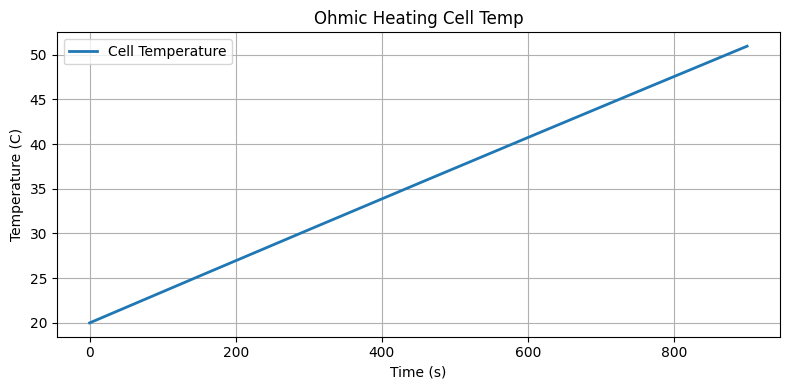

In [38]:
time = np.arange(num_steps) * dt

plt.figure(figsize=(8, 4))
plt.plot(time, temp_cells, linewidth=2, label="Cell Temperature")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (C)")
plt.title("Ohmic Heating Cell Temp")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()